# 03 — LSTM Autoencoder for Sequence Anomaly Detection

Train on normal transactions only. Anomaly score = reconstruction error.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from src.data.generator import generate_transactions, get_train_test_split
from src.data.preprocessor import preprocess
from src.models.autoencoder import train_autoencoder, reconstruction_errors
from src.evaluation.metrics import evaluate, plot_score_distributions
plt.rcParams['figure.dpi'] = 120

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

df = generate_transactions(n=20_000, fraud_rate=0.02, seed=42)
X_train, X_test, y_train, y_test = get_train_test_split(df, seed=42)
X_train_s, X_test_s, pipe = preprocess(X_train, X_test)

# Train ONLY on normal transactions — autoencoder learns to reconstruct normal patterns
X_train_normal = X_train_s[y_train.values == 0]
print(f"Training on {len(X_train_normal):,} normal transactions")

Device: cpu
Training on 15,680 normal transactions


In [2]:
n_features = X_train_s.shape[1]
print(f"n_features = {n_features}")

model, history = train_autoencoder(
    X_train_normal,
    n_features=n_features,
    hidden_dim=64,
    latent_dim=16,
    epochs=30,
    batch_size=256,
    lr=1e-3,
    device=device,
    verbose=True,
)
print(f"\nFinal training loss: {history[-1]:.6f}")

n_features = 13


  Epoch   5/30 | Loss: 0.279041


  Epoch  10/30 | Loss: 0.150452


  Epoch  15/30 | Loss: 0.135165


  Epoch  20/30 | Loss: 0.116658


  Epoch  25/30 | Loss: 0.109365


  Epoch  30/30 | Loss: 0.104639

Final training loss: 0.104639


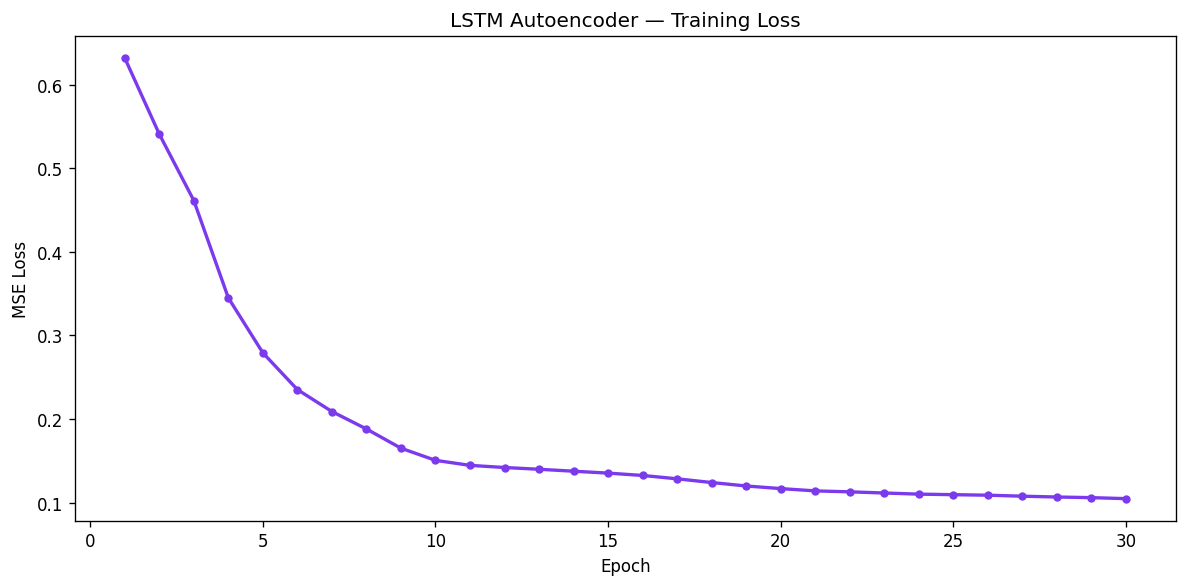

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(history)+1), history, 'o-', color='#7c3aed', lw=2, ms=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder — Training Loss')
plt.tight_layout()
plt.savefig('../outputs/figures/03_ae_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

Reconstruction error stats:
  Normal  — mean: 0.0948  std: 0.5125
  Fraud   — mean: 18.0107  std: 26.3745



AUC-PR=0.825  AUC-ROC=0.978


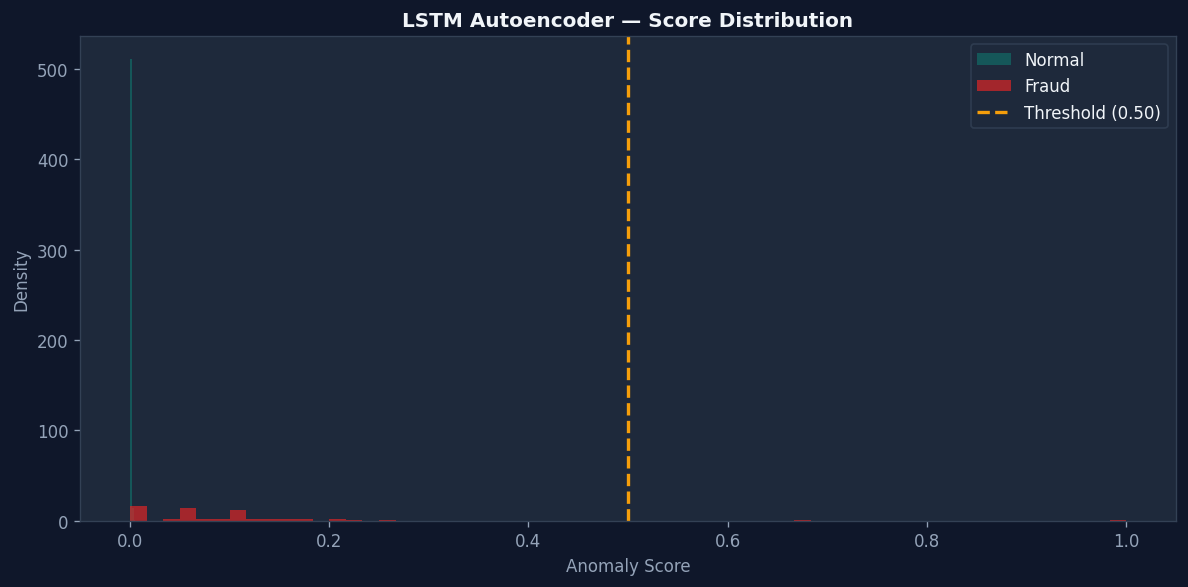

In [4]:
ae_errors = reconstruction_errors(model, X_test_s, device=device)
y_true = y_test.values

print("Reconstruction error stats:")
print(f"  Normal  — mean: {ae_errors[y_true==0].mean():.4f}  std: {ae_errors[y_true==0].std():.4f}")
print(f"  Fraud   — mean: {ae_errors[y_true==1].mean():.4f}  std: {ae_errors[y_true==1].std():.4f}")

from sklearn.metrics import average_precision_score, roc_auc_score
from src.models.isolation_forest import anomaly_scores_if
from src.models.ensemble import normalise

ae_scores = normalise(ae_errors)
ap  = average_precision_score(y_true, ae_scores)
auc = roc_auc_score(y_true, ae_scores)
print(f"\nAUC-PR={ap:.3f}  AUC-ROC={auc:.3f}")

plot_score_distributions(y_true, ae_scores, model_name='LSTM Autoencoder',
                         threshold=0.50, save_path='../outputs/figures/03_ae_score_dist.png')

## Reconstruction Error Analysis by Typology

In [5]:
from src.data.generator import FEATURE_COLS

# Attach errors back to test dataframe
test_idx = X_test.index
test_df = df.loc[test_idx].copy().reset_index(drop=True)
test_df['ae_error'] = ae_errors
test_df['is_fraud_flag'] = y_true

for typology_col, condition in [
    ('Structuring',   (test_df['amount'].between(8000,9999)) & (test_df['is_fraud_flag']==1)),
    ('High Velocity', (test_df['n_txn_last_1h']>=8) & (test_df['is_fraud_flag']==1)),
    ('Geo Risk',      (test_df['country_risk']==2) & (test_df['is_fraud_flag']==1)),
]:
    subset = test_df[condition]
    if len(subset) > 0:
        print(f"  {typology_col:15s}  n={len(subset):3d}  mean_error={subset['ae_error'].mean():.4f}")

  Structuring      n=  9  mean_error=5.5054
  High Velocity    n= 18  mean_error=27.7950
  Geo Risk         n= 30  mean_error=6.8460
